# GreenStep actions — single-city extraction demo (Rochester)

A worked demonstration of the per-city action detail that lives on each `city-detail/<id>` page — the data with no bulk export (README → Canonical downloads). It parses a captured excerpt of Rochester's page (`https://greenstep.pca.state.mn.us/city-detail/12396`) into one tidy row per completed action, to show exactly which fields are available.

**Scope of this demo.** The excerpt embedded below is the first six best practices (25 completed actions of Rochester's 89) — as far as the page-text capture reached, since long detail pages exceed a single text fetch. It is enough to demonstrate the structure; the full page needs a raw-HTML fetch (see Findings). Nothing here is a committed production table — it is a sample.

## 1. Captured page excerpt
The embedded string mirrors the page's text markers: `## <category>`, `### [<best practice>](url) {BP no.N}`, `N star - Action K:`, and the date/year/file lines under each action. Kept inline so the notebook runs anywhere with no network or fixture file.

In [1]:
CAPTURE = r"""
## Buildings and Lighting Buildings and Lighting
### [Efficient Existing Public Buildings](https://greenstep.pca.state.mn.us/bp-detail/81714) {BP no.1}
1 star - Action 1:
Date action report first entered: 06/01/2011
Year action initially completed:
Descriptive File:
2 star - Action 2:
Date action report first entered: 06/13/2011
Year action initially completed:
Descriptive File:
1 star - Action 5:
Date action report first entered: 06/01/2011
Year action initially completed:
Descriptive File:
2 star - Action 7:
Date action report first entered: 10/15/2013
Year action initially completed:
Descriptive File: [view file](https://greenstep.pca.state.mn.us/sites/default/files/1.7RochesterActionFile.pdf)
### [Efficient Existing Private Buildings](https://greenstep.pca.state.mn.us/bp-detail/81715) {BP no.2}
2 star - Action 1:
Date action report first entered: 07/26/2011
Year action initially completed:
Descriptive File:
3 star - Action 5:
Date action report first entered: 05/31/2011
Year action initially completed:
Descriptive File:
2 star - Action 6:
Date action report first entered: 05/31/2011
Year action initially completed: 2005
Descriptive File:
### [New Green Buildings](https://greenstep.pca.state.mn.us/bp-detail/81716) {BP no.3}
1 star - Action 1:
Date action report first entered: 06/13/2011
Year action initially completed:
Descriptive File:
1 star - Action 2:
Date action report first entered: 07/26/2011
Year action initially completed:
Descriptive File:
1 star - Action 3:
Date action report first entered: 08/01/2011
Year action initially completed:
Descriptive File:
3 star - Action 4:
Date action report first entered: 06/09/2011
Year action initially completed:
Descriptive File:
### [Efficient Outdoor Lighting and Signals](https://greenstep.pca.state.mn.us/bp-detail/81717) {BP no.4}
2 star - Action 2:
Date action report first entered: 07/26/2011
Year action initially completed:
Descriptive File:
1 star - Action 3:
Date action report first entered: 07/26/2011
Year action initially completed:
Descriptive File:
1 star - Action 4:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
1 star - Action 5:
Date action report first entered: 06/01/2011
Year action initially completed:
Descriptive File:
3 star - Action 8:
Date action report first entered: 06/01/2011
Year action initially completed:
Descriptive File:
### [Building Redevelopment](https://greenstep.pca.state.mn.us/bp-detail/81740) {BP no.5}
1 star - Action 1:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
1 star - Action 2:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
1 star - Action 3:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
1 star - Action 3:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
1 star - Action 4:
Date action report first entered: 06/14/2011
Year action initially completed:
Descriptive File:
2 star - Action 5:
Date action report first entered: 06/01/2011
Year action initially completed:
Descriptive File:
## Land Use Land Use
### [Comprehensive, Climate and Energy Plans](https://greenstep.pca.state.mn.us/bp-detail/81718) {BP no.6}
1 star - Action 1:
Date action report first entered: 01/27/2011
Year action initially completed:
Descriptive File:
1 star - Action 2:
Date action report first entered: 05/16/2011
Year action initially completed:
Descriptive File:
1 star - Action 3:
Date action report first entered: 05/17/2011
Year action initially completed:
Descriptive File:
"""
print("captured lines:", len(CAPTURE.strip().splitlines()))

captured lines: 108


## 2. Parse to one row per completed action
Walk the lines, carrying the current category and best practice, and open a new record on each `N star - Action K:` marker. Category names are doubled on the page (`Buildings and Lighting Buildings and Lighting`), so de-double them.

In [2]:
import re, pandas as pd
from pathlib import Path

def dedouble(s):
    s = s.strip()
    if len(s) % 2 == 1 and s[:len(s)//2].strip() == s[len(s)//2:].strip():
        return s[:len(s)//2].strip()
    half = len(s)//2
    return s[:half].strip() if s[:half].strip() == s[half:].strip() else s

rows, cat, bp_name, bp_no, cur = [], None, None, None, None
for line in CAPTURE.strip().splitlines():
    line = line.strip()
    if line.startswith("## "):
        cat = dedouble(line[3:])
    elif line.startswith("### "):
        m = re.match(r"### \[(.*?)\]\((.*?)\)\s*\{BP no\.(\d+)\}", line)
        if m: bp_name, bp_url, bp_no = m.group(1), m.group(2), int(m.group(3))
    elif re.match(r"^\d star - Action \d+:", line):
        m = re.match(r"^(\d) star - Action (\d+):", line)
        cur = {"community":"Rochester","city_detail_id":12396,"category":cat,
               "best_practice":bp_name,"bp_no":bp_no,"action_no":int(m.group(2)),
               "star_rating":int(m.group(1)),"date_first_entered":None,
               "year_completed":None,"descriptive_file_url":None}
        rows.append(cur)
    elif line.startswith("Date action report first entered:") and cur is not None:
        cur["date_first_entered"] = line.split(":",1)[1].strip() or None
    elif line.startswith("Year action initially completed:") and cur is not None:
        cur["year_completed"] = line.split(":",1)[1].strip() or None
    elif line.startswith("Descriptive File:") and cur is not None:
        m = re.search(r"\((https?://[^)]+)\)", line)
        cur["descriptive_file_url"] = m.group(1) if m else None

actions = pd.DataFrame(rows)
actions["date_first_entered"] = pd.to_datetime(actions["date_first_entered"], format="%m/%d/%Y", errors="coerce")
actions.head(10)

,community,city_detail_id,category,best_practice,bp_no,action_no,star_rating,date_first_entered,year_completed,descriptive_file_url
0,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,1,1,2011-06-01,None,None
1,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,2,2,2011-06-13,None,None
2,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,5,1,2011-06-01,None,None
3,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,7,2,2013-10-15,None,https://greenstep.pca.state.mn.us/sites/defaul...
4,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,1,2,2011-07-26,None,None
5,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,5,3,2011-05-31,None,None
6,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,6,2,2011-05-31,2005,None
7,Rochester,12396,Buildings and Lighting,New Green Buildings,3,1,1,2011-06-13,None,None
8,Rochester,12396,Buildings and Lighting,New Green Buildings,3,2,1,2011-07-26,None,None
9,Rochester,12396,Buildings and Lighting,New Green Buildings,3,3,1,2011-08-01,None,None


## 3. Validate
Expected shape, star values, and the one known source quirk: Building Redevelopment lists Action 3 twice.

In [3]:
assert len(actions) == 25, len(actions)
assert set(actions.star_rating) <= {1,2,3}
assert actions.category.nunique() == 2 and actions.bp_no.nunique() == 6
dup = actions[actions.duplicated(["bp_no","action_no"], keep=False)]
assert len(dup) == 2 and dup.bp_no.iloc[0] == 5, "expected the BP5 Action-3 duplicate"
print("25 actions, 6 best practices, 2 categories | star mix:", actions.star_rating.value_counts().sort_index().to_dict())
print("known quirk retained: BP5 lists Action 3 twice (dedupe on (bp_no, action_no) if a unique set is needed)")

25 actions, 6 best practices, 2 categories | star mix: {1: 16, 2: 6, 3: 3}
known quirk retained: BP5 lists Action 3 twice (dedupe on (bp_no, action_no) if a unique set is needed)


## 4. Export the sample
Written to `data/` as a clearly-labelled sample, not a production table.

In [4]:
DATA = Path("data"); DATA.mkdir(exist_ok=True)
out = DATA / "greenstep_actions_sample_rochester_12396.csv"
actions.to_csv(out, index=False)
print("wrote", out, "rows:", len(actions))
actions

wrote data/greenstep_actions_sample_rochester_12396.csv rows: 25


,community,city_detail_id,category,best_practice,bp_no,action_no,star_rating,date_first_entered,year_completed,descriptive_file_url
0,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,1,1,2011-06-01,None,None
1,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,2,2,2011-06-13,None,None
2,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,5,1,2011-06-01,None,None
3,Rochester,12396,Buildings and Lighting,Efficient Existing Public Buildings,1,7,2,2013-10-15,None,https://greenstep.pca.state.mn.us/sites/defaul...
4,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,1,2,2011-07-26,None,None
5,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,5,3,2011-05-31,None,None
6,Rochester,12396,Buildings and Lighting,Efficient Existing Private Buildings,2,6,2,2011-05-31,2005,None
7,Rochester,12396,Buildings and Lighting,New Green Buildings,3,1,1,2011-06-13,None,None
8,Rochester,12396,Buildings and Lighting,New Green Buildings,3,2,1,2011-07-26,None,None
9,Rochester,12396,Buildings and Lighting,New Green Buildings,3,3,1,2011-08-01,None,None


## 5. What the sample shows
Actions per best practice and the star mix — the shape of a single city's completed-action record.

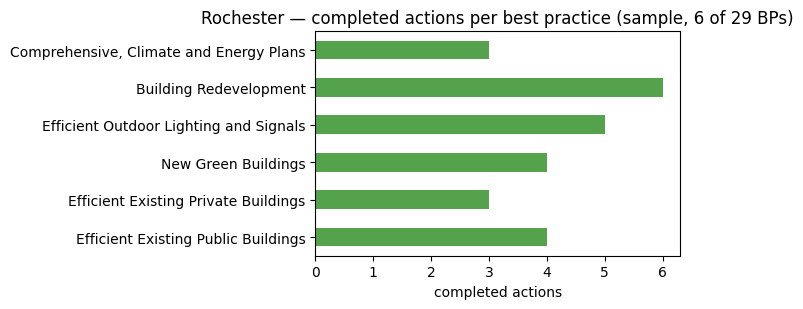

,bp_no,best_practice,actions
0,1,Efficient Existing Public Buildings,4
1,2,Efficient Existing Private Buildings,3
2,3,New Green Buildings,4
3,4,Efficient Outdoor Lighting and Signals,5
4,5,Building Redevelopment,6
5,6,"Comprehensive, Climate and Energy Plans",3


In [5]:
import matplotlib.pyplot as plt
by_bp = actions.groupby(["bp_no","best_practice"]).size().rename("actions").reset_index()
ax = by_bp.set_index("best_practice")["actions"].plot.barh(color="#54A24B", figsize=(7,3.2))
ax.set_title("Rochester — completed actions per best practice (sample, 6 of 29 BPs)")
ax.set_xlabel("completed actions"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
by_bp

## 6. Findings

**What each city-detail page yields.** One row per completed action, with: category (five program areas), best practice (29 total, each with a stable `bp-detail` id), action number within the best practice, star rating (1–3 = the implementation depth the community reported), the date the action report was first entered, an optional year the action was initially completed, and an optional descriptive-file PDF. This demo produced 25 such rows for Rochester across its first six best practices; the live page holds 89.

**Why this is a sample, not the full extract.** The per-city detail is only on the `city-detail/<id>` HTML page — no bulk export — and a single text fetch truncates long pages partway (here, after best practice 6). A full extraction reads the raw HTML of each of the ~156 pages (ids harvested from `/all-cities`) and parses the same markers this notebook uses. The parser here is the reusable core of that job.

**One quirk to carry forward.** Building Redevelopment lists Action 3 twice for Rochester; dedupe on (best_practice, action_no) when a unique action set is needed. This mirrors the West Saint Paul duplicate-rows quirk noted for the all-cities list in the README.